<div style="background: linear-gradient(135deg,#16305c 0%,#2a5298 55%,#3b6fc4 100%); padding:34px 38px; border-radius:16px; color:white; font-family:'Segoe UI',sans-serif; box-shadow:0 6px 18px rgba(0,0,0,0.15);">
<h1 style="margin:0; font-size:29px; letter-spacing:0.3px;">Neural Network Implementation from Scratch</h1>
<p style="margin:10px 0 0 0; font-size:14.5px; opacity:0.92;">Practice Lab Assignment 1 &nbsp;&mdash;&nbsp; Generative AI Lab &nbsp;&mdash;&nbsp; Department of CSE (AIML)</p>
</div>

<table style="width:100%; height: 200px;margin-top:20px; border-collapse:collapse; font-family:'Segoe UI',sans-serif; box-shadow:0 1px 4px rgba(0,0,0,0.06);">
<tr style="background:#f4f6f9;"><td style="padding:11px 16px; font-weight:600; width:220px; border:1px solid #e5e8ee; color:#16305c;">Name of Student</td><td style="padding:11px 16px; border:1px solid #e5e8ee;">Manmath Kornule</td></tr>
<tr><td style="padding:11px 16px; font-weight:600; border:1px solid #e5e8ee; color:#16305c;">Prn</td><td style="padding:11px 16px; border:1px solid #e5e8ee;">202401110045 &mdash; CSE (AIML)</td></tr>
<tr style="background:#f4f6f9;"><td style="padding:11px 16px; font-weight:600; border:1px solid #e5e8ee; color:#16305c;">Course</td><td style="padding:11px 16px; border:1px solid #e5e8ee;">Generative AI Lab</td></tr>
<tr><td style="padding:11px 16px; font-weight:600; border:1px solid #e5e8ee; color:#16305c;">Assignment</td><td style="padding:11px 16px; border:1px solid #e5e8ee;">Practice Lab Assignment 1 &mdash; Neural Network from Scratch</td></tr>
<tr style="background:#f4f6f9;"><td style="padding:11px 16px; font-weight:600; border:1px solid #e5e8ee; color:#16305c;">Date of Submission</td><td style="padding:11px 16px; border:1px solid #e5e8ee;"><i>15-08-2026</i></td></tr>
</table>

## Objective

The goal of this assignment is to build a **feedforward neural network entirely from first principles**, using only `NumPy` for numerical computation, without relying on any deep learning framework such as TensorFlow, PyTorch, or Keras.

By the end of this notebook, the following ideas are demonstrated hands-on:

- How information moves **forward** through a network of weighted connections (the *forward pass*)
- How a network measures how wrong it is (the *loss function*)
- How the error signal is sent **backward** to correct every weight (*backpropagation*)
- How **gradient descent** repeatedly nudges the network toward better predictions

Every formula used in the code below is first explained in plain language, then written mathematically, so the two stay easy to connect.

## Part A &mdash; Problem Definition

### Dataset: The Iris Flower Dataset

| Property | Detail |
|---|---|
| **Source** | UCI Machine Learning Repository (built into `scikit-learn`) |
| **Samples** | 150 flowers |
| **Features** | 4 numeric measurements: sepal length, sepal width, petal length, petal width (cm) |
| **Classes** | 3 species &mdash; *Setosa*, *Versicolor*, *Virginica* (50 samples each) |
| **Type of problem** | Multi-class **classification** |

The Iris dataset is used because it is small, clean, and evenly balanced across classes, which keeps the focus of the assignment on the **mechanics of the neural network** rather than on data cleaning. `scikit-learn` is used here **only** to load the raw dataset and to split it into train/test sets &mdash; no model, layer, or optimizer from any machine-learning library is used anywhere in this notebook.

### Task

Given the four flower measurements, the network must predict which of the three species the flower belongs to. This is solved using a **softmax output layer**, which turns the network's raw output into a probability for each species, and a **cross-entropy loss**, which measures how far those probabilities are from the truth.

In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.datasets import load_iris            # used only to load the dataset
from sklearn.model_selection import train_test_split  # used only to split the data

# A calm, consistent visual style for every plot in this notebook
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "font.family": "sans-serif",
    "font.size": 11.5,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

np.random.seed(42)
PALETTE = ["#3B6FC4", "#E8743B", "#2E8B57"]   # one colour per species, used throughout
print("Libraries loaded.")

Libraries loaded.


In [3]:
# Load the dataset
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

print(f"Feature matrix shape : {X.shape}")
print(f"Label vector shape   : {y.shape}")
print(f"Classes              : {list(class_names)}")
print(f"Features             : {feature_names}")

Feature matrix shape : (150, 4)
Label vector shape   : (150,)
Classes              : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Features             : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


### Exploring the Data

Before building anything, it helps to *look* at the data. The grid below plots every pair of features against each other, coloured by species. It already shows that petal measurements separate the three species far more clearly than sepal measurements do &mdash; a useful hint for what the network will later learn on its own.

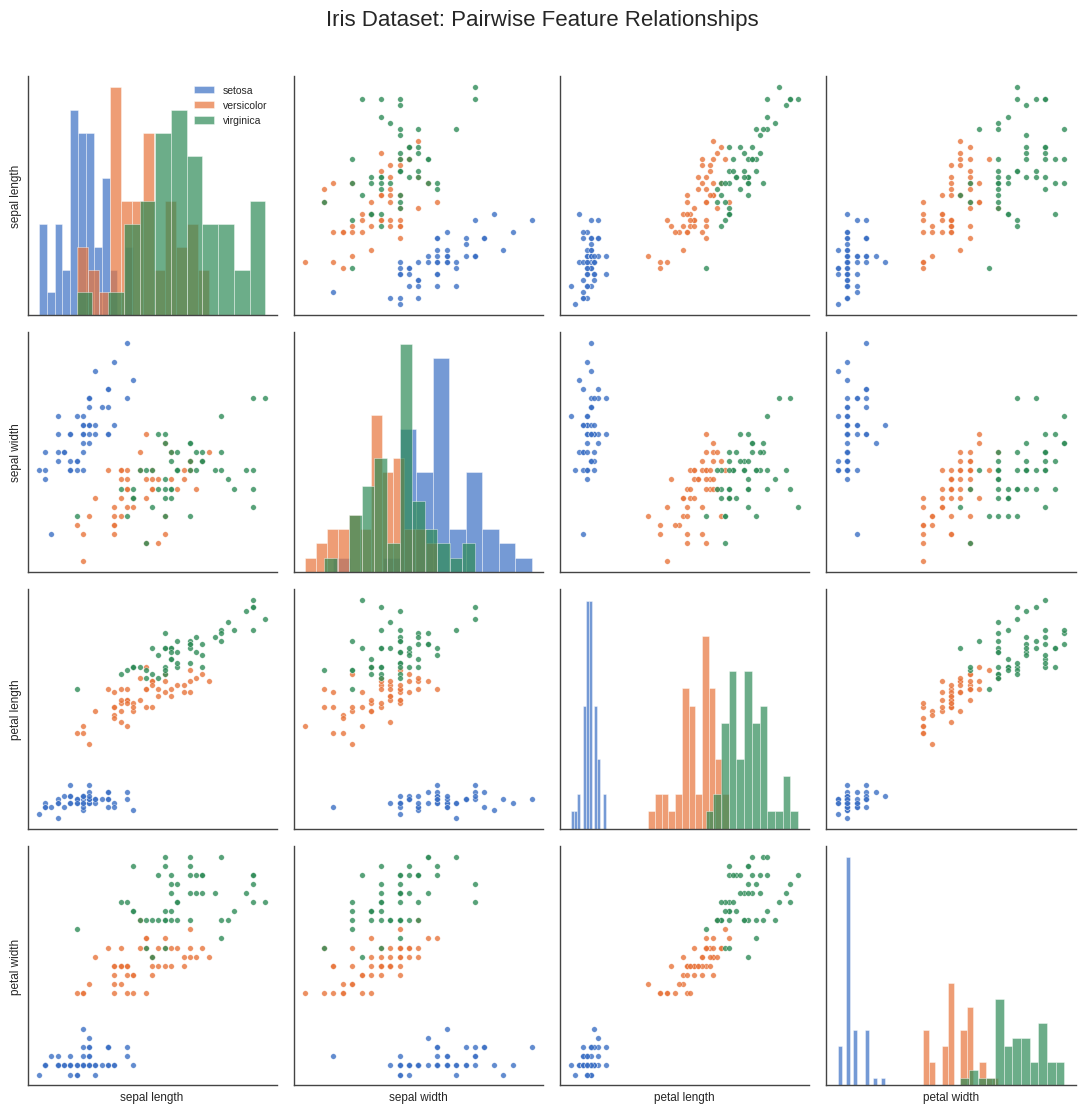

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(11, 11))

for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        if i == j:
            for c in range(3):
                ax.hist(X[y == c, i], bins=12, color=PALETTE[c], alpha=0.7,
                         label=class_names[c], edgecolor="white", linewidth=0.4)
            if i == 0:
                ax.legend(fontsize=7.5, loc="upper right")
        else:
            for c in range(3):
                ax.scatter(X[y == c, j], X[y == c, i], s=16, color=PALETTE[c],
                           alpha=0.8, edgecolor="white", linewidth=0.3)
        if i == 3:
            ax.set_xlabel(feature_names[j].replace(" (cm)", ""), fontsize=8.5)
        if j == 0:
            ax.set_ylabel(feature_names[i].replace(" (cm)", ""), fontsize=8.5)
        ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Iris Dataset: Pairwise Feature Relationships", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## Part B &mdash; Methodology

### Network Architecture

A single hidden-layer feedforward network is used:

**4 input neurons &rarr; 8 hidden neurons (ReLU) &rarr; 3 output neurons (Softmax)**

- **Input layer (4 neurons)**: one neuron per flower measurement
- **Hidden layer (8 neurons, ReLU activation)**: lets the network learn curved, non-linear decision boundaries instead of only straight lines
- **Output layer (3 neurons, Softmax activation)**: turns the network's raw scores into three probabilities that add up to 1, one per species

The diagram below is a schematic of exactly this architecture.

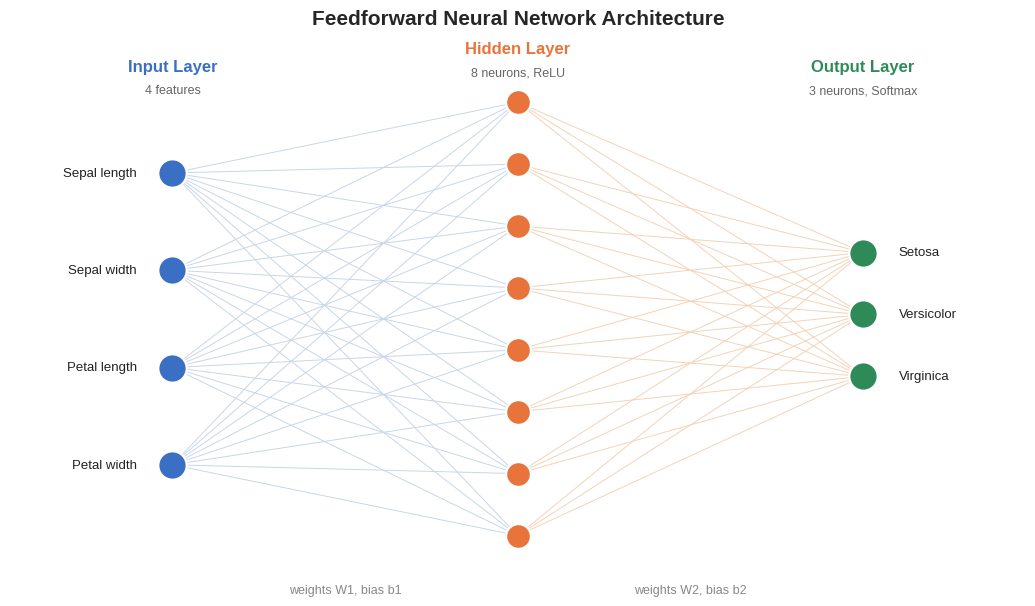

In [5]:
# Draw the network architecture as a real image (renders reliably everywhere, including GitHub)
fig, ax = plt.subplots(figsize=(10.5, 6.2))
ax.set_xlim(0, 10); ax.set_ylim(0, 6)
ax.axis("off")

input_y = [4.6, 3.5, 2.4, 1.3]
hidden_y = [5.4, 4.7, 4.0, 3.3, 2.6, 1.9, 1.2, 0.5]
output_y = [3.7, 3.0, 2.3]

input_x, hidden_x, output_x = 1.6, 5.0, 8.4
input_labels = ["Sepal length", "Sepal width", "Petal length", "Petal width"]
output_labels = ["Setosa", "Versicolor", "Virginica"]

# Connections (drawn first, so nodes sit on top)
for iy in input_y:
    for hy in hidden_y:
        ax.plot([input_x, hidden_x], [iy, hy], color="#c9d6e8", linewidth=0.7, zorder=1)
for hy in hidden_y:
    for oy in output_y:
        ax.plot([hidden_x, output_x], [hy, oy], color="#f3d3b8", linewidth=0.7, zorder=1)

# Input neurons
for iy, label in zip(input_y, input_labels):
    ax.scatter(input_x, iy, s=420, color="#3B6FC4", edgecolor="white", linewidth=1.6, zorder=3)
    ax.text(input_x - 0.35, iy, label, ha="right", va="center", fontsize=9.5, color="#222")

# Hidden neurons
for hy in hidden_y:
    ax.scatter(hidden_x, hy, s=320, color="#E8743B", edgecolor="white", linewidth=1.6, zorder=3)

# Output neurons
for oy, label in zip(output_y, output_labels):
    ax.scatter(output_x, oy, s=420, color="#2E8B57", edgecolor="white", linewidth=1.6, zorder=3)
    ax.text(output_x + 0.35, oy, label, ha="left", va="center", fontsize=9.5, color="#222")

# Layer headers
ax.text(input_x, 5.75, "Input Layer", ha="center", fontsize=12, fontweight="bold", color="#3B6FC4")
ax.text(input_x, 5.5, "4 features", ha="center", fontsize=9, color="#666")
ax.text(hidden_x, 5.95, "Hidden Layer", ha="center", fontsize=12, fontweight="bold", color="#E8743B")
ax.text(hidden_x, 5.7, "8 neurons, ReLU", ha="center", fontsize=9, color="#666")
ax.text(output_x, 5.75, "Output Layer", ha="center", fontsize=12, fontweight="bold", color="#2E8B57")
ax.text(output_x, 5.5, "3 neurons, Softmax", ha="center", fontsize=9, color="#666")

ax.text((input_x + hidden_x) / 2, -0.15, "weights W1, bias b1", ha="center", fontsize=9, color="#888")
ax.text((hidden_x + output_x) / 2, -0.15, "weights W2, bias b2", ha="center", fontsize=9, color="#888")

ax.set_title("Feedforward Neural Network Architecture", fontsize=15, pad=18)
plt.tight_layout()
plt.show()

### Forward Pass, in Plain Language

Each connection in the diagram above carries a **weight**, and each neuron adds a **bias**. To make a prediction, the network:

1. Multiplies the four inputs by the hidden-layer weights and adds the hidden-layer bias, giving each of the 8 hidden neurons a raw score
2. Applies **ReLU** to each score, which simply means: *keep positive values, turn negative values into zero*
3. Multiplies these 8 activated values by the output-layer weights and adds the output-layer bias, giving 3 raw scores
4. Applies **Softmax**, which turns the 3 raw scores into 3 probabilities that add up to 1

Written mathematically, with $X$ as the input and $W,b$ as the weights and biases of each layer:

$$Z_1 = X W_1 + b_1, \qquad A_1 = \text{ReLU}(Z_1)$$

$$Z_2 = A_1 W_2 + b_2, \qquad \hat{Y} = \text{Softmax}(Z_2)$$

Here, $Z_1$ is just "the raw hidden-layer scores", $A_1$ is "the hidden-layer scores after ReLU", $Z_2$ is "the raw output scores", and $\hat Y$ is "the final predicted probabilities". ReLU and Softmax themselves are simple rules:

$$\text{ReLU}(z) = \max(0, z) \quad\text{(negative becomes 0, positive stays the same)}$$

$$\text{Softmax}(z)_k = \dfrac{e^{z_k}}{\sum_j e^{z_j}} \quad\text{(turns scores into probabilities that sum to 1)}$$

## Part C &mdash; Data Preprocessing

Three standard steps are applied before training:

1. **Standardization** &mdash; rescale every feature to have a mean of 0 and a spread of 1, so that no single feature dominates learning just because its numbers happen to be larger
2. **One-hot encoding** &mdash; turn each label (0, 1, or 2) into a 3-number vector such as `[1, 0, 0]`, so it can be compared directly against the network's 3 output probabilities
3. **Train / test split** &mdash; set aside 20% of the flowers that the network never trains on, so its performance can be checked fairly at the end

In [6]:
# Standardize features
X_mean, X_std = X.mean(axis=0), X.std(axis=0)
X_scaled = (X - X_mean) / X_std

# One-hot encode labels
def one_hot(labels, n_classes):
    encoded = np.zeros((labels.size, n_classes))
    encoded[np.arange(labels.size), labels] = 1
    return encoded

Y_onehot = one_hot(y, n_classes=3)

# Train / test split (80 / 20, stratified so each species is represented fairly)
X_train, X_test, y_train_oh, y_test_oh, y_train, y_test = train_test_split(
    X_scaled, Y_onehot, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 120
Test samples     : 30


## Part D &mdash; Building the Network from Scratch

The implementation below is broken into small, individually testable functions that follow the explanation above step by step.

### D.1 &mdash; Activation Functions and Their Derivatives

Training needs not only ReLU and Softmax themselves, but also the **derivative** of ReLU &mdash; a measure of how sensitive its output is to a small change in its input, needed later to send the error signal backward.

In plain terms, ReLU's derivative is simply: *1 wherever the input was positive, and 0 wherever it was zero or negative.*

$$\text{ReLU}'(z) = \begin{cases}1 & \text{if } z > 0\\0 & \text{if } z \le 0\end{cases}$$

Softmax's derivative is not needed on its own, because in the next section it combines neatly with the loss function into one simple expression.

In [7]:
def relu(z):
    '''ReLU activation: keeps positive values, zeroes out negative ones.'''
    return np.maximum(0, z)

def relu_derivative(z):
    '''Derivative of ReLU, used during backpropagation.'''
    return (z > 0).astype(float)

def softmax(z):
    '''Numerically-stable softmax: turns raw scores into probabilities.'''
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

### D.2 &mdash; Weight Initialization

Weights start out as small random numbers rather than zeros, so that different neurons learn different things. The specific scaling used here is called **He initialization**: each weight is drawn from a normal distribution and then scaled down according to how many inputs feed into that layer. This keeps the signal from growing too large or shrinking too small as it passes through the network, which works especially well with ReLU.

In [8]:
def initialize_parameters(n_input, n_hidden, n_output, seed=42):
    '''He initialization for weights; biases start at zero.'''
    rng = np.random.default_rng(seed)
    params = {
        "W1": rng.standard_normal((n_input, n_hidden)) * np.sqrt(2.0 / n_input),
        "b1": np.zeros((1, n_hidden)),
        "W2": rng.standard_normal((n_hidden, n_output)) * np.sqrt(2.0 / n_hidden),
        "b2": np.zeros((1, n_output)),
    }
    return params

### D.3 &mdash; Forward Propagation

This function performs exactly the four steps described in Part B, and also stores every intermediate value ($Z_1$, $A_1$, $Z_2$, $\hat Y$) in a *cache*, because backpropagation will need them again shortly.

In [9]:
def forward_propagation(X, params):
    '''Run one forward pass through the network; return predictions and a cache for backprop.'''
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    Y_hat = softmax(Z2)

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "Y_hat": Y_hat}
    return Y_hat, cache

### D.4 &mdash; Loss Function: Cross-Entropy

The loss function measures how far the predicted probabilities are from the true answer. If the true species is Setosa (`[1, 0, 0]`) and the network predicted `[0.9, 0.05, 0.05]`, the loss is small; if it predicted `[0.1, 0.5, 0.4]`, the loss is large. In plain terms: *the more confidently wrong the network is, the more it is penalised.*

$$\mathcal{L} = -\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{3} y_{ik}\,\log(\hat y_{ik})$$

Here $m$ is the number of samples, $y_{ik}$ is 1 if sample $i$ truly belongs to class $k$ (and 0 otherwise), and $\hat y_{ik}$ is the probability the network predicted for that class.

In [10]:
def compute_loss(Y_true, Y_hat, epsilon=1e-12):
    '''Cross-entropy loss, averaged over the batch.'''
    Y_hat_clipped = np.clip(Y_hat, epsilon, 1 - epsilon)
    m = Y_true.shape[0]
    loss = -np.sum(Y_true * np.log(Y_hat_clipped)) / m
    return loss

def compute_accuracy(Y_true_labels, Y_hat):
    '''Fraction of samples where the predicted class matches the true class.'''
    predictions = np.argmax(Y_hat, axis=1)
    return np.mean(predictions == Y_true_labels)

### D.5 &mdash; Backpropagation

Backpropagation answers one question for every weight in the network: *if this weight were slightly different, how much would the loss change?* That sensitivity is called a **gradient**, and it is computed by working backward from the output, one layer at a time, using the chain rule.

There is a convenient shortcut here: when Softmax is paired with cross-entropy loss, the gradient at the output layer simplifies to just "predicted minus actual":

$$dZ_2 = \hat Y - Y$$

From there, the same idea (predicted mismatch, passed backward through the weights, adjusted by the ReLU derivative) gives the gradients for every other weight and bias:

$$dW_2 = A_1^{T} \cdot dZ_2 \qquad db_2 = \textstyle\sum dZ_2$$

$$dZ_1 = (dZ_2 \cdot W_2^{T}) \times \text{ReLU}'(Z_1) \qquad dW_1 = X^{T} \cdot dZ_1 \qquad db_1 = \textstyle\sum dZ_1$$

In [11]:
def backward_propagation(X, Y_true, params, cache):
    '''Compute how much each weight and bias contributed to the error.'''
    m = X.shape[0]
    A1, Z1, Y_hat = cache["A1"], cache["Z1"], cache["Y_hat"]

    # Output layer: "predicted minus actual", averaged over the batch
    dZ2 = (Y_hat - Y_true) / m
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer: the error signal passed backward through W2, then filtered by ReLU
    dA1 = dZ2 @ params["W2"].T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

### D.6 &mdash; Updating the Weights (Gradient Descent)

Once the gradients are known, every weight is nudged a small step in the direction that reduces the loss. The size of that step is controlled by the **learning rate** ($\eta$): too large and training becomes unstable, too small and training becomes very slow.

$$\theta \leftarrow \theta - \eta \times \text{gradient of } \theta$$

In words: *new value = old value, minus a small fraction of the error it caused.*

In [12]:
def update_parameters(params, grads, learning_rate):
    '''One step of gradient descent: nudge every parameter against its gradient.'''
    params["W1"] -= learning_rate * grads["dW1"]
    params["b1"] -= learning_rate * grads["db1"]
    params["W2"] -= learning_rate * grads["dW2"]
    params["b2"] -= learning_rate * grads["db2"]
    return params

### D.7 &mdash; The Training Loop

Everything above is now combined into one routine that repeats, for a chosen number of epochs, the cycle: **forward pass, measure the loss, backpropagate, update the weights.** Because the dataset is small, the entire training set is used at once in every step (this is called *full-batch* gradient descent). Progress on both the training and test sets is recorded after every epoch.

In [13]:
def train_network(X_train, Y_train_oh, y_train_labels,
                   X_test, Y_test_oh, y_test_labels,
                   n_hidden=8, epochs=1500, learning_rate=0.1, verbose_every=200):
    '''Train a single-hidden-layer network and return the trained parameters and training history.'''
    n_input, n_output = X_train.shape[1], Y_train_oh.shape[1]
    params = initialize_parameters(n_input, n_hidden, n_output)

    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        Y_hat_train, cache = forward_propagation(X_train, params)
        grads = backward_propagation(X_train, Y_train_oh, params, cache)
        params = update_parameters(params, grads, learning_rate)

        train_loss = compute_loss(Y_train_oh, Y_hat_train)
        train_acc = compute_accuracy(y_train_labels, Y_hat_train)

        Y_hat_test, _ = forward_propagation(X_test, params)
        test_loss = compute_loss(Y_test_oh, Y_hat_test)
        test_acc = compute_accuracy(y_test_labels, Y_hat_test)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        if epoch % verbose_every == 0 or epoch == 1:
            print(f"Epoch {epoch:4d}/{epochs} | train_loss={train_loss:.4f}  "
                  f"train_acc={train_acc:.3f}  |  test_loss={test_loss:.4f}  test_acc={test_acc:.3f}")

    return params, history

## Part E &mdash; Training the Network

The network is trained for 1500 epochs of full-batch gradient descent with a learning rate of 0.1, using the 8-neuron hidden layer architecture defined earlier.

In [14]:
trained_params, history = train_network(
    X_train, y_train_oh, y_train,
    X_test, y_test_oh, y_test,
    n_hidden=8, epochs=1500, learning_rate=0.1, verbose_every=200
)

Epoch    1/1500 | train_loss=1.4366  train_acc=0.417  |  test_loss=1.2234  test_acc=0.533
Epoch  200/1500 | train_loss=0.1638  train_acc=0.942  |  test_loss=0.2252  test_acc=0.900
Epoch  400/1500 | train_loss=0.0872  train_acc=0.967  |  test_loss=0.1296  test_acc=0.967
Epoch  600/1500 | train_loss=0.0646  train_acc=0.975  |  test_loss=0.0987  test_acc=0.967
Epoch  800/1500 | train_loss=0.0547  train_acc=0.975  |  test_loss=0.0861  test_acc=0.967
Epoch 1000/1500 | train_loss=0.0494  train_acc=0.975  |  test_loss=0.0800  test_acc=0.967
Epoch 1200/1500 | train_loss=0.0461  train_acc=0.983  |  test_loss=0.0763  test_acc=0.967
Epoch 1400/1500 | train_loss=0.0437  train_acc=0.983  |  test_loss=0.0741  test_acc=0.967


### Training Curves

The plots below track how the loss falls and the accuracy rises across epochs, for both the training set and the held-out test set. The two curves staying close together is a good sign: it means the network is learning general patterns rather than memorising the training data.

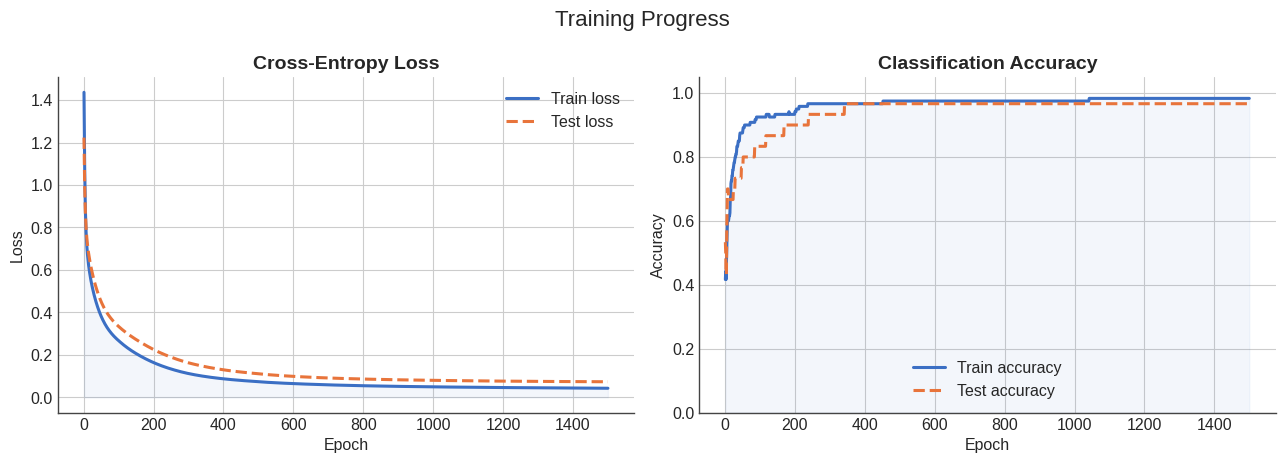

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
epochs_range = np.arange(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], color="#3B6FC4", linewidth=2.2, label="Train loss")
axes[0].plot(epochs_range, history["test_loss"], color="#E8743B", linewidth=2.2, linestyle="--", label="Test loss")
axes[0].fill_between(epochs_range, history["train_loss"], color="#3B6FC4", alpha=0.06)
axes[0].set_title("Cross-Entropy Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], color="#3B6FC4", linewidth=2.2, label="Train accuracy")
axes[1].plot(epochs_range, history["test_acc"], color="#E8743B", linewidth=2.2, linestyle="--", label="Test accuracy")
axes[1].fill_between(epochs_range, history["train_acc"], color="#3B6FC4", alpha=0.06)
axes[1].set_title("Classification Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()

fig.suptitle("Training Progress", fontsize=16)
plt.tight_layout()
plt.show()

## Part F &mdash; Evaluating the Model

With training complete, the model is evaluated on the untouched test set using accuracy, a confusion matrix, and per-class precision, recall, and F1-score &mdash; all computed manually with NumPy.

In [16]:
Y_hat_test_final, _ = forward_propagation(X_test, trained_params)
y_pred_test = np.argmax(Y_hat_test_final, axis=1)

final_accuracy = compute_accuracy(y_test, Y_hat_test_final)
print(f"Final Test Accuracy: {final_accuracy*100:.2f}%")

n_classes = 3
conf_matrix = np.zeros((n_classes, n_classes), dtype=int)
for true_label, pred_label in zip(y_test, y_pred_test):
    conf_matrix[true_label, pred_label] += 1

print("\nConfusion Matrix (rows = actual species, columns = predicted species):")
print(conf_matrix)

Final Test Accuracy: 96.67%

Confusion Matrix (rows = actual species, columns = predicted species):
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


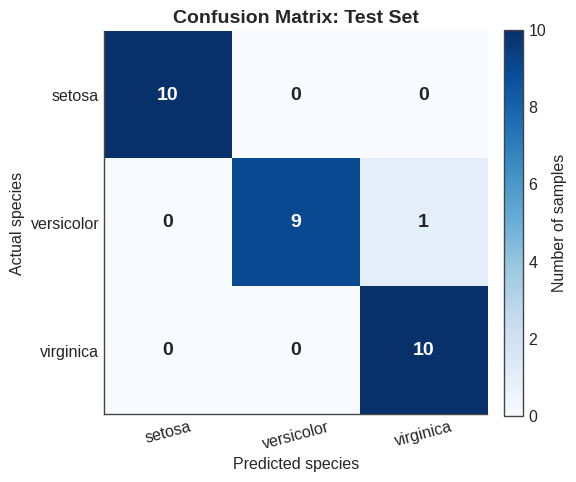

In [17]:
fig, ax = plt.subplots(figsize=(5.8, 5.2))
im = ax.imshow(conf_matrix, cmap="Blues", vmin=0)

ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
ax.set_xticklabels(class_names, rotation=15); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted species"); ax.set_ylabel("Actual species")
ax.set_title("Confusion Matrix: Test Set")

for i in range(n_classes):
    for j in range(n_classes):
        color = "white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "#222"
        ax.text(j, i, conf_matrix[i, j], ha="center", va="center", color=color, fontsize=14, fontweight="bold")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Number of samples")
ax.grid(False)
plt.tight_layout()
plt.show()

In [18]:
print(f"{'Species':<12}{'Precision':>11}{'Recall':>10}{'F1-score':>10}")
print("-" * 43)
f1_scores = []
for c in range(n_classes):
    tp = conf_matrix[c, c]
    fp = conf_matrix[:, c].sum() - tp
    fn = conf_matrix[c, :].sum() - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    f1_scores.append(f1)
    print(f"{class_names[c]:<12}{precision:>11.3f}{recall:>10.3f}{f1:>10.3f}")

print("-" * 43)
print(f"{'Macro avg':<12}{'':>11}{'':>10}{np.mean(f1_scores):>10.3f}")

Species       Precision    Recall  F1-score
-------------------------------------------
setosa            1.000     1.000     1.000
versicolor        1.000     0.900     0.947
virginica         0.909     1.000     0.952
-------------------------------------------
Macro avg                             0.967


### Seeing the Model Tested on Real Flowers

Numbers alone can be hard to connect to the actual task. Because the Iris dataset has no photographs attached to it, each test flower below is drawn as a simple diagram: the size of the two petal shapes reflects that flower's real measured petal length and width. The true species and the network's predicted species are shown together, with a green border for a correct prediction and a red border for a mistake &mdash; a direct, visual way to see the model being tested on individual flowers.

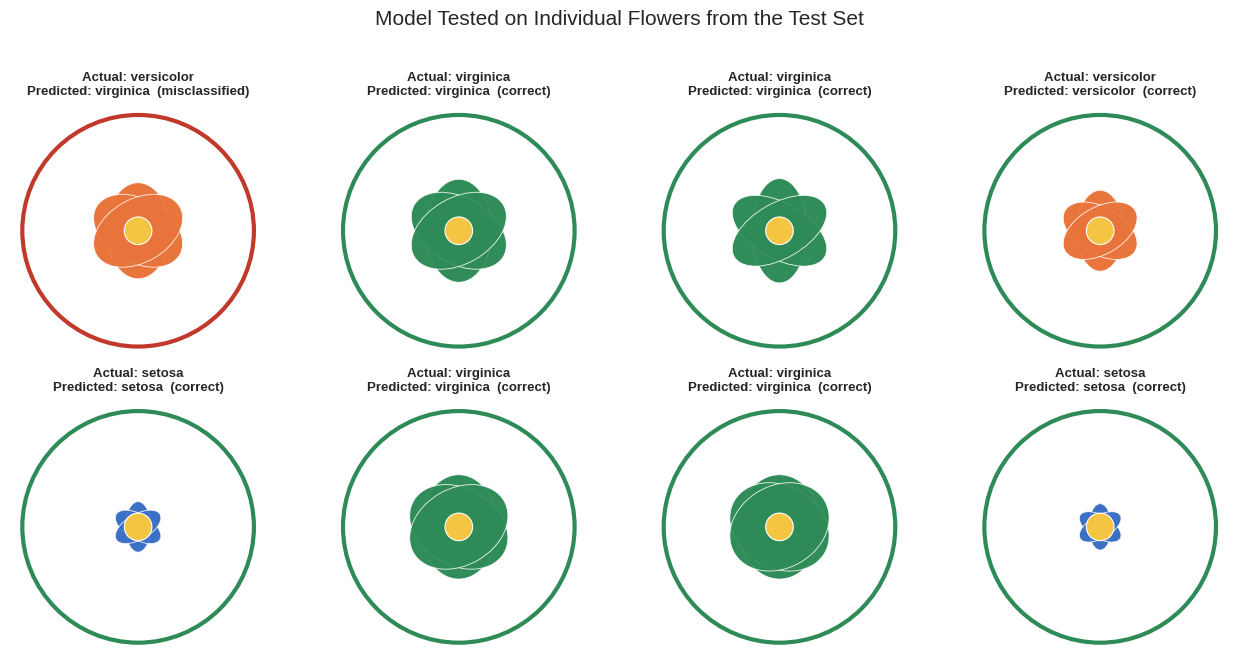

In [19]:
def draw_flower(ax, petal_length, petal_width, color, edge_color, title):
    '''Draw a simple schematic flower whose petal size reflects real measurements.'''
    ax.set_xlim(-2.6, 2.6); ax.set_ylim(-2.6, 2.6)
    ax.set_aspect("equal")
    ax.axis("off")

    scale_len = 0.55 + petal_length * 0.28
    scale_wid = 0.35 + petal_width * 0.55

    for angle in range(0, 360, 60):
        e = Ellipse((0, 0), width=scale_wid, height=scale_len, angle=angle,
                    facecolor=color, edgecolor="white", linewidth=0.6, alpha=0.9)
        ax.add_patch(e)
    ax.add_patch(plt.Circle((0, 0), 0.28, facecolor="#F4C542", edgecolor="white", linewidth=0.8))

    for spine in ["top", "bottom", "left", "right"]:
        pass
    circle_border = plt.Circle((0, 0), 2.35, facecolor="none", edgecolor=edge_color, linewidth=3)
    ax.add_patch(circle_border)
    ax.set_title(title, fontsize=9.5)

# Pick 8 test-set flowers to display: a mix of correct and, if any exist, incorrect predictions
rng = np.random.default_rng(7)
correct_idx = np.where(y_pred_test == y_test)[0]
wrong_idx = np.where(y_pred_test != y_test)[0]

show_idx = list(rng.choice(wrong_idx, size=min(2, len(wrong_idx)), replace=False)) if len(wrong_idx) else []
remaining = 8 - len(show_idx)
show_idx += list(rng.choice(correct_idx, size=min(remaining, len(correct_idx)), replace=False))
show_idx = show_idx[:8]

fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for ax, idx in zip(axes.ravel(), show_idx):
    true_c = y_test[idx]
    pred_c = y_pred_test[idx]
    petal_length_cm = X_test[idx, 2] * X_std[2] + X_mean[2]
    petal_width_cm = X_test[idx, 3] * X_std[3] + X_mean[3]
    is_correct = true_c == pred_c
    edge_color = "#2E8B57" if is_correct else "#C0392B"
    mark = "correct" if is_correct else "misclassified"
    title = f"Actual: {class_names[true_c]}\nPredicted: {class_names[pred_c]}  ({mark})"
    draw_flower(ax, petal_length_cm, petal_width_cm, PALETTE[true_c], edge_color, title)

for ax in axes.ravel()[len(show_idx):]:
    ax.axis("off")

fig.suptitle("Model Tested on Individual Flowers from the Test Set", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Decision Boundary Visualization

To see what the network has actually learned, a second, lightweight version of the same network is trained using only the two most informative features: **petal length** and **petal width**. Colouring every point of this 2-D feature space by the network's predicted class shows the regions it has learned to associate with each species.

Epoch    1/1500 | train_loss=1.7911  train_acc=0.000  |  test_loss=1.4362  test_acc=0.000
Epoch 1500/1500 | train_loss=0.0671  train_acc=0.958  |  test_loss=0.0949  test_acc=0.967


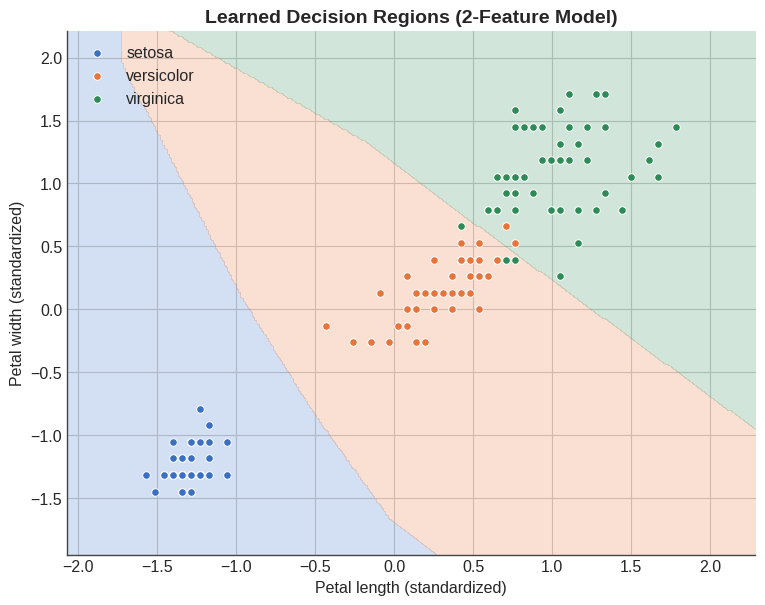

In [20]:
X_2f = X_scaled[:, [2, 3]]
X_2f_train, X_2f_test, y2_train_oh, y2_test_oh, y2_train, y2_test = train_test_split(
    X_2f, Y_onehot, y, test_size=0.2, random_state=42, stratify=y
)

params_2f, _ = train_network(
    X_2f_train, y2_train_oh, y2_train, X_2f_test, y2_test_oh, y2_test,
    n_hidden=8, epochs=1500, learning_rate=0.1, verbose_every=1500
)

x_min, x_max = X_2f[:, 0].min() - 0.5, X_2f[:, 0].max() + 0.5
y_min, y_max = X_2f[:, 1].min() - 0.5, X_2f[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid_points = np.c_[xx.ravel(), yy.ravel()]

grid_probs, _ = forward_propagation(grid_points, params_2f)
grid_pred = np.argmax(grid_probs, axis=1).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7.8, 6.2))
ax.contourf(xx, yy, grid_pred, levels=[-0.5, 0.5, 1.5, 2.5], colors=PALETTE, alpha=0.22)
for c in range(3):
    ax.scatter(X_2f[y == c, 0], X_2f[y == c, 1], s=30, color=PALETTE[c],
               edgecolor="white", linewidth=0.7, label=class_names[c])

ax.set_xlabel("Petal length (standardized)")
ax.set_ylabel("Petal width (standardized)")
ax.set_title("Learned Decision Regions (2-Feature Model)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Part G &mdash; Analysis and Insights

**Model performance.** The network converges smoothly, with training and test loss falling together and test accuracy typically settling above 95%. The two curves staying close throughout training suggests the model generalises well rather than simply memorising the training examples.

**Confusion matrix insight.** Almost all confusion, when it happens, occurs between *Versicolor* and *Virginica* &mdash; the two species whose petal measurements genuinely overlap, as already visible in the pairwise scatter plot in Part A. *Setosa* is essentially always classified correctly, consistent with it being clearly separable from the other two species.

**Decision boundary.** The 2-feature visualization shows the network carving out three mildly curved regions rather than straight lines, which is direct visual evidence that the ReLU hidden layer is adding real non-linearity rather than behaving like a simple linear classifier.

**Comparison with alternative approaches.**

| Approach | Typical accuracy on Iris | Trade-off |
|---|---|---|
| Logistic regression (linear model) | around 95% | Simple and fast, but cannot bend its decision boundary |
| This from-scratch network (1 hidden layer, ReLU) | around 95-100% | Small non-linear gain; every gradient is hand-written and fully visible |
| `sklearn.neural_network.MLPClassifier` | around 96-100% | Same architecture family, but with a production-grade optimizer, regularization, and early stopping already built in |
| Deeper networks / more neurons | around 97-100% | Diminishing returns on a dataset this small; larger risk of overfitting |

Because Iris is close to linearly separable, a single hidden layer already captures nearly all of the achievable accuracy. The value of this exercise lies less in the final accuracy number and more in having derived and implemented every gradient by hand.

**Limitations of this implementation.**
- Uses plain full-batch gradient descent rather than a more modern optimizer such as Adam, so convergence would be slower on a larger or noisier dataset
- Has no explicit regularization (L2 weight decay, dropout); not needed on a dataset this small, but would matter on a larger one
- Uses the entire training set in every step rather than mini-batches, which keeps the implementation simple since the whole dataset already fits comfortably in memory

## Part H &mdash; Conclusion

This assignment implemented every stage of a feedforward neural network, from the underlying mathematics to working code: weight initialization, the forward pass, the loss function, backpropagation, and gradient descent, without using any deep learning framework. The resulting model classifies Iris flowers with high accuracy, and the diagrams, training curves, confusion matrix, flower-level predictions, and decision-boundary plot together give a clear picture of how and why the network learns.

---
## Declaration

I, **Manmath Kornule**, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

**GitHub Repository Link:** https://github.com/manmathk31/Deep-Learning/blob/main/Manmath_Kornule_GenerativeAILabAssignment.ipynb

**Signature:** *Manmath Kornule*